In [1]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
import itertools
from matplotlib import gridspec
from tqdm import tqdm

from joblib import Parallel, delayed

import sys
sys.path.append('../../code/6_CRM')
from CRM import CRM
from CRM_utils import has_converged


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [2]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


# run = '20251219-000823'
run = '20260129-111722'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)


run_simulations = True

In [3]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [4]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])

# Identify communities with high and low average richness

In [5]:
mean_richness = df.groupby('i')['richness'].mean()

In [6]:
bottom_10 = mean_richness.sort_values().index[:1000]
rich_10 = mean_richness.sort_values().index[-1000:]

In [7]:
C_bottom = []
C_rich = []

for i in bottom_10:
    C_bottom.append(data[f'C_{i}'])
for i in rich_10:
    C_rich.append(data[f'C_{i}'])

# Niche overlap

In [8]:
def niche_overlap(C):
    """Compute the average niche overlap between species in a community."""
    overlaps = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        overlaps_ij = np.sum((ci*cj).astype(bool))/np.sum((ci+cj).astype(bool))
        overlaps.append(overlaps_ij)
    return np.mean(overlaps)

In [9]:
noi_bottom = []
noi_rich = []
for C in C_bottom:
    noi_bottom.append(niche_overlap(C))
for C in C_rich:
    noi_rich.append(niche_overlap(C))


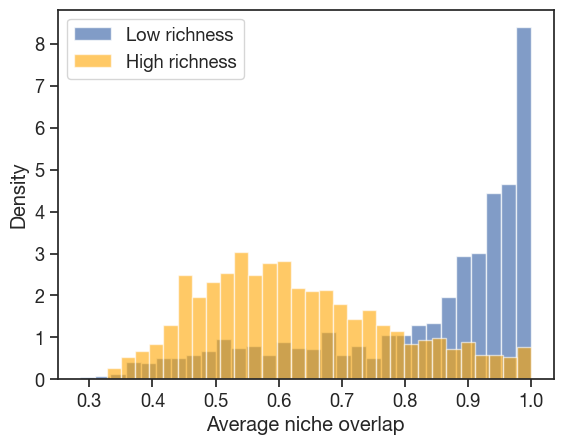

In [10]:
plt.hist(noi_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(noi_rich, bins=30, alpha=0.6, label='High richness', color='orange', density=True)
plt.xlabel('Average niche overlap')
plt.ylabel('Density')
plt.legend()

In [11]:
# Euclidean distance in consumption space
def euclidean_distance_C(C):
    """Compute the average Euclidean distance between species in consumption space."""
    distances = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        dist_ij = np.linalg.norm(ci - cj)
        distances.append(dist_ij)
    return np.mean(distances)

In [12]:
edc_bottom = []
edc_rich = []
for C in C_bottom:
    edc_bottom.append(euclidean_distance_C(C))
for C in C_rich:
    edc_rich.append(euclidean_distance_C(C))



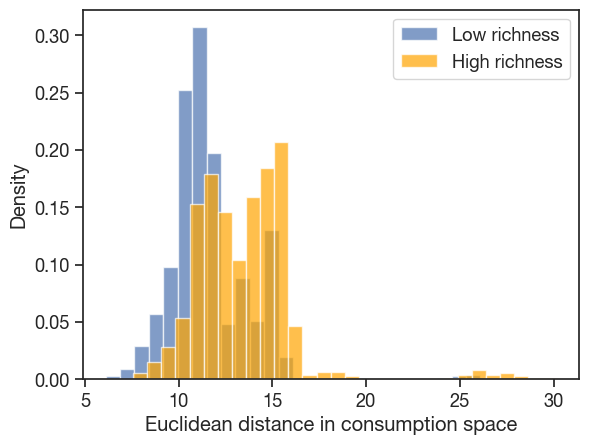

In [13]:
plt.hist(edc_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(edc_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in consumption space')
plt.ylabel('Density')
plt.legend()

# Private niches


In [14]:
(C.astype(bool).sum(axis = 0) == 1).sum()

np.int64(0)

In [15]:
def private_niches(C, fraction=True):
    """Compute the fraction of private niches in a community."""
    if fraction:
        return (C.astype(bool).sum(axis = 0) == 1).sum() / C.shape[1]
    else:
        return (C.astype(bool).sum(axis = 0) == 1).sum()

In [16]:
pn_bottom = []
pn_rich = []
for C in C_bottom:
    pn_bottom.append(private_niches(C, fraction=True))
for C in C_rich:
    pn_rich.append(private_niches(C, fraction=True))

Text(0, 0.5, 'Density')

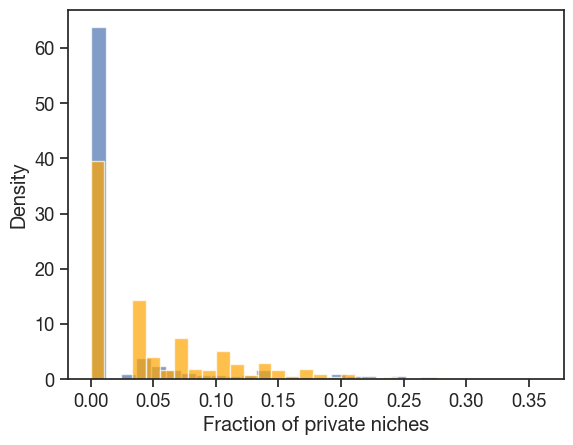

In [17]:
plt.hist(pn_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(pn_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Fraction of private niches')
plt.ylabel('Density')

# Average Km distance

In [18]:
def K_log_eucledian_distance(K):
    distances = []
    S = K.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ki = np.log10(K[i, :])
        kj = np.log10(K[j, :])
        dist_ij = np.linalg.norm(ki - kj)
        distances.append(dist_ij)
    return np.mean(distances)


In [19]:
ked_bottom = []
ked_rich = []
for i in bottom_10:
    K = data[f'K_{i}']
    ked_bottom.append(K_log_eucledian_distance(K))
for i in rich_10:
    K = data[f'K_{i}']
    ked_rich.append(K_log_eucledian_distance(K))

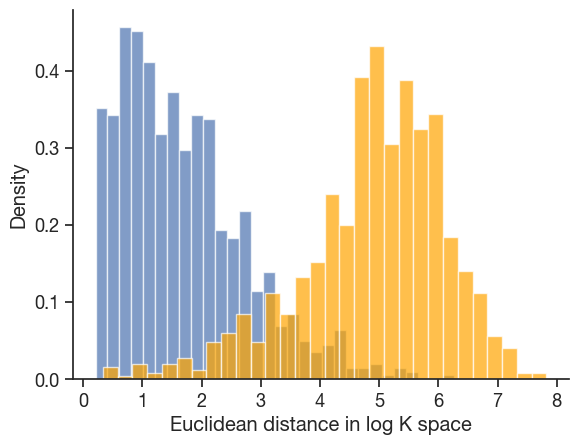

In [20]:
plt.hist(ked_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ked_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log K space')
plt.ylabel('Density')
sns.despine()

# Log K distance and niche overlap

In [21]:
len(list(bottom_10) + list(rich_10))

2000

In [22]:
plot_df = pd.DataFrame(index = list(bottom_10) + list(rich_10))
plot_df['richness'] = list(mean_richness.loc[bottom_10]) + list(mean_richness.loc[rich_10])
plot_df['noi'] = noi_bottom + noi_rich
plot_df['edc'] = edc_bottom + edc_rich
plot_df['ked'] = ked_bottom + ked_rich
plot_df['Category'] = ['Low richness']*len(bottom_10) + ['High richness']*len(rich_10)


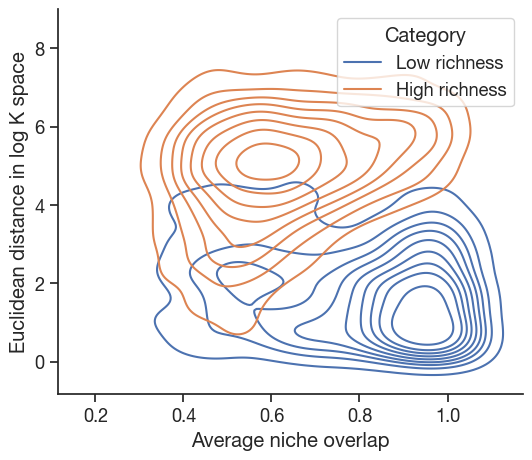

In [23]:
fig, ax = plt.subplots(figsize=(6,5))
sns.kdeplot(data=plot_df, x='noi', y = 'ked', hue = 'Category')
plt.xlabel('Average niche overlap')
plt.ylabel('Euclidean distance in log K space')
sns.despine()

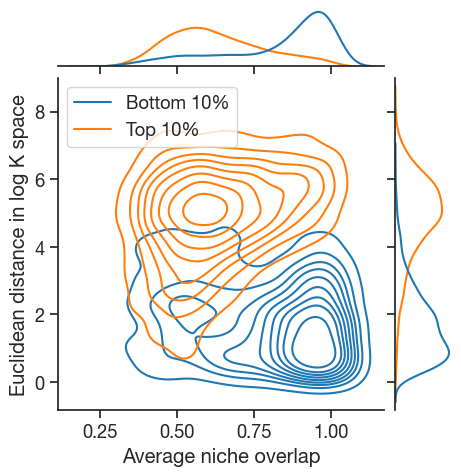

In [24]:
g = sns.jointplot(data=plot_df, x='noi', y='ked', hue='Category', kind='kde', height=5, palette = 'tab10')#, cut = 0)
g.ax_joint.set_xlabel('Average niche overlap')
g.ax_joint.set_ylabel('Euclidean distance in log K space')
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(0, 1), title='')
# g.ax_joint.set_xlim(.3,1)
# g.ax_joint.set_ylim(0, 8)

# Change legende labels
new_labels = ['Bottom 10%', 'Top 10%']
for t, l in zip(g.ax_joint.get_legend().texts, new_labels):
    t.set_text(l) 

plt.savefig(figure_folder / 'community_properties_noi_ked.pdf', dpi=300, bbox_inches='tight')

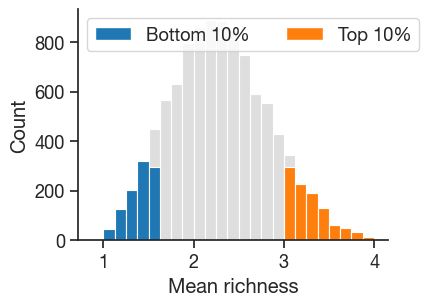

In [25]:
fig, ax = plt.subplots(figsize=(4,3))

# Calculate bin edges first
bin_edges = np.histogram_bin_edges(mean_richness, bins=25)
g = sns.histplot(mean_richness, ax = ax, bins = bin_edges, color = 'lightgray')
sns.histplot(data=plot_df, x='richness', hue='Category', palette = 'tab10', ax = ax, bins = bin_edges, alpha = 1)
sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(0, 1), title='', ncol=2)
# Change legende labels
new_labels = ['Bottom 10%', 'Top 10%']
for t, l in zip(ax.get_legend().texts, new_labels):
    t.set_text(l) 
plt.xlabel('Mean richness')
plt.savefig(figure_folder / 'richness_hist.pdf', dpi=300, bbox_inches='tight')

# C/K ratio

In [26]:
def CK_euclidean_distance(CK_ratio):
    distances = []
    S = CK_ratio.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        cki = np.log10(CK_ratio[i, :])
        ckj = np.log10(CK_ratio[j, :])
        # Replace inf with a small number
        cki = np.where(np.isinf(cki), -3, cki)
        ckj = np.where(np.isinf(ckj), -3, ckj)
        
        dist_ij = np.linalg.norm(cki - ckj)
        distances.append(dist_ij)
    return np.mean(distances)

In [27]:
np.log10(0)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_89347/135924841.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(0)


np.float64(-inf)

In [28]:
# Perform cell-by-cell division of C on K
ckd_bottom = []
for i in bottom_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_bottom.append(CK_euclidean_distance(CK_ratio))
ckd_rich = []
for i in rich_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_rich.append(CK_euclidean_distance(CK_ratio))

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_89347/1167146942.py:5: RuntimeWarning: divide by zero encountered in log10
  cki = np.log10(CK_ratio[i, :])
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_89347/1167146942.py:6: RuntimeWarning: divide by zero encountered in log10
  ckj = np.log10(CK_ratio[j, :])


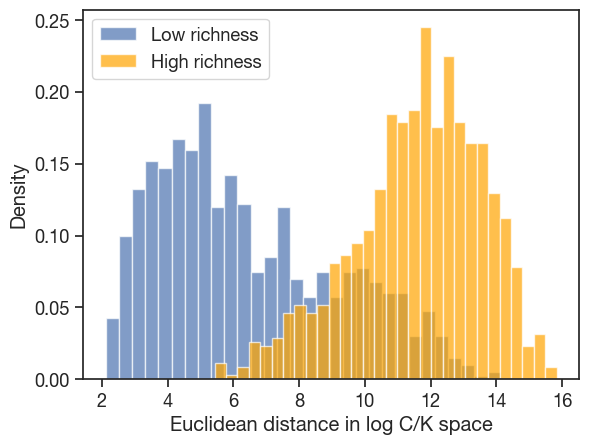

In [29]:
plt.hist(ckd_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ckd_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log C/K space')
plt.ylabel('Density')
plt.legend()

In [30]:
df_mean = df.groupby('i').agg({'richness':('mean', 'std')}).reset_index()

In [31]:
df_mean.columns = ['i', 'richness_mean', 'richness_std']

In [32]:
noi_data = []
for i in df_mean['i']:
    noi_data.append(niche_overlap(data[f'C_{i}']))
df_mean['noi'] = noi_data

Text(0, 0.5, 'Average niche overlap')

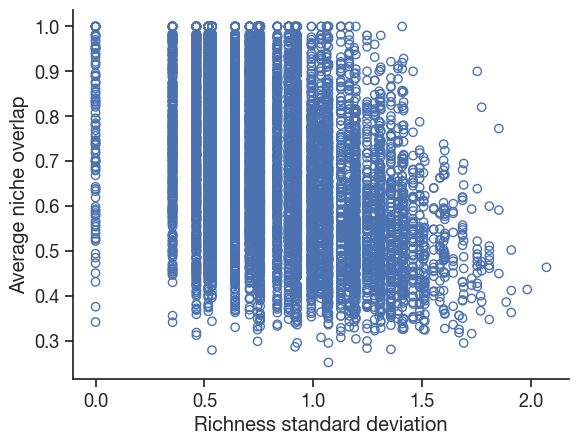

In [33]:
plt.scatter(df_mean['richness_std'], df_mean['noi'], marker = 'o', facecolor='none', edgecolor='b')
sns.despine()
plt.xlabel('Richness standard deviation')
plt.ylabel('Average niche overlap')

In [34]:
st.pearsonr(df_mean['richness_std'], df_mean['noi'])

PearsonRResult(statistic=np.float64(-0.41949744015463164), pvalue=np.float64(0.0))

# Monoculture experiments

In [35]:
indices = list(bottom_10) + list(rich_10)

In [36]:
# if run_simulations:
#     max_time = 200
#     initial_abundance = 1e-3


#     dt = 1
#     method = 'LSODA'
#     initial_c_conc = 10
#     N0 = np.ones(1) * initial_abundance
#     R_min_values = []
#     iterations = 8
#     monoculture_data = []

#     # for i, sdata in enumerate(tqdm(selected_data[::5])):
#     for i in tqdm(indices):
#         n_cs = df.loc[df.i==i, 'n_cs'].values[0]
#         sdata = {'C': data[f'C_{i}'],
#                 'D': data[f'D_{i}'],
#                 'K': data[f'K_{i}']
#         }

#         for j in range(iterations):
#             R0 = np.zeros(n_cs)
#             R0[j] = initial_c_conc
#             C = sdata['C']
#             D = sdata['D']
#             K = sdata['K']
#             l = args.leakage*np.ones(1)

#             for k in range(4):
#                 if C[k,0]<1e-6:
#                     # No growth
#                     continue
#                 c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=1e-3, l=l,  K=K[k, None])
#                 # sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
#                 try:
#                     sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
#                     # muMatrix,kMatrix,dTensor,lVector,delta,Ns,Nr,N0,R0,t_max):
#                     # sol, success = run_lsoda_crossfeeding(C[k, None], K[k, None], D[k, None], l, 0, 1, n_cs, N0, R0, max_time)
#                 except (RuntimeError, ValueError):
#                     print('Error: ', i, k)
#                     monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
#                 else:
#                     N = c.N[-1, :]
#                     R = c.R[-1, :]
#                     monoculture_data.append({'final_abundance': N, 'final_resources': R, 'species_no': k, 'i': i, 'j':j})
#                     # R_min_values.append(np.min(R[-1]))
def run_single_monoculture(i, j, k, C, D, K, n_cs, leakage, max_time, initial_abundance, initial_c_conc, dt, method):
    """Run a single monoculture simulation"""
    # if C[k, j] < 1e-6:
    #     return None
    
    N0 = np.ones(1) * initial_abundance
    R0 = np.zeros(n_cs)
    R0[j] = initial_c_conc
    l = leakage * np.ones(1)
    
    c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
    
    try:
        sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
        N = c.N[-1, :]
        R = c.R[-1, :]
        return {'final_abundance': N, 'final_resources': R, 'species_no': k, 'i': i, 'j': j}
    except (RuntimeError, ValueError):
        print('Error: ', i, k)
        return {'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j': j}

if run_simulations:
    max_time = 200
    initial_abundance = 1e-5
    dt = 1
    method = 'LSODA'
    initial_c_conc = 10
    iterations = 8
    
    # Prepare all simulation parameters
    sim_params = []
    for i in indices:
        n_cs = df.loc[df.i==i, 'n_cs'].values[0]
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        
        for j in range(iterations):
            for k in range(4):
                sim_params.append((i, j, k, C, D, K, n_cs, args.leakage, max_time, 
                                 initial_abundance, initial_c_conc, dt, method))
    
    # Run in parallel
    m_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_monoculture)(*params) for params in sim_params
    )
    
    # Filter out None results
    monoculture_data = [r for r in m_results if r is not None]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19856756622540303s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.050000905990600586s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  59 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.12662982940673828s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    2.7s
[Parallel(n_job

Error:  8264 1


[Parallel(n_jobs=-1)]: Done 47720 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 48608 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done 49496 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 50400 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 51304 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 52224 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 53144 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 54080 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 55016 tasks      | elapsed:  5.2min
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


Error:  2564 0


[Parallel(n_jobs=-1)]: Done 55968 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done 56920 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 57888 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 58856 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 59840 tasks      | elapsed:  5.8min
[Parallel(n_jobs=-1)]: Done 60824 tasks      | elapsed:  5.9min
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


Error:  8240 3


[Parallel(n_jobs=-1)]: Done 61824 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done 62824 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 63840 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done 64000 out of 64000 | elapsed:  6.3min finished


In [ ]:
len(monoculture_data)

5384

In [38]:
fn_mono = results_folder / f'{run}_monocultures.npz'

with open(fn_mono, 'wb') as f:
    np.savez(f, monoculture_data)

# Spent medium cultivations

In [39]:
# if run_simulations:
#     spent_monoculture_data = []
        
#     for mcdata in tqdm(monoculture_data):
#         if np.isnan(mcdata['final_abundance']) or mcdata['final_abundance'] == initial_abundance:
#             continue
#         if mcdata['final_resources'][0]>0.5*initial_c_conc:
#             # Discard spent media from communities that did not consume most of the primary resource
#             continue
#         i = mcdata['i']
#         j = mcdata['j']
#         k_spent = mcdata['species_no']
#         C = data[f'C_{i}']
#         D = data[f'D_{i}']
#         K = data[f'K_{i}']
#         l = args.leakage * np.ones(1)
#         R0 = mcdata['final_resources']
#         R0[R0<0] = 0
#         N0 = np.ones(1) * initial_abundance
#         n_cs = R0.shape[0]
#         for k in range(4):
#             if k != k_spent:
#                 c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
#                 try:
#                     sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
#                 except (RuntimeError, ValueError):
#                     print('Error: ', i, j, k)
#                     # spent_monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
#                 else:
#                     if sol.success:
#                         spent_monoculture_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :], 'spent_medium_from': k_spent, 'species_no': k, 'i': i, 'j':j})
            
def run_single_spent_medium(i, j, k_spent,n_cs, R0, C, D, K, leakage, max_time, initial_abundance, dt, method, initial_c_conc=10):
    """Run a single spent medium simulation"""    

    l = leakage * np.ones(1)
    N0 = np.ones(1) * initial_abundance
    results = []
    for k in range(4):
        if k != k_spent:
            c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
            try:
                sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
                if sol.success:
                    results.append({
                        'final_abundance': c.N[-1, :], 
                        'final_resources': c.R[-1, :], 
                        'spent_medium_from': k_spent, 
                        'species_no': k, 
                        'i': i, 
                        'j': j,
                        'R0': R0[j],
                        't_max': sol.t[-1]
                    })
            except (RuntimeError, ValueError):
                print('Error: ', i, j, k)
    
    return results if results else None

if run_simulations:
    # Prepare data for parallel processing
    sm_params = []
    for mcdata in monoculture_data:
        j = mcdata['j']
        i = mcdata['i']

        if np.isnan(mcdata['final_abundance']).any() or (mcdata['final_abundance'] == initial_abundance).any():
            continue
        if mcdata['final_resources'][j] > 0.1*initial_c_conc:
            continue
    
        
        
        k_spent = mcdata['species_no']

        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        R0 = mcdata['final_resources']
        R0[R0<0] = 0
        n_cs = R0.shape[0]

        sm_params.append((i, j,k_spent, n_cs, R0, C, D, K, args.leakage, max_time, initial_abundance, dt, method, initial_c_conc))
    
    


In [40]:
# c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
# sol = c.run(max_time, np.ones(1), R0, dt=dt, method=method, max_calls=1e5)

In [41]:
if run_simulations:
    # Run in parallel
    sm_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_spent_medium)(*params) for params in sm_params
    )

spent_monoculture_data = [item for r in sm_results if r is not None for item in r]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1843849589362406s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04457688331604004s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.025795936584472656s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 102 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09840893745422363s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 160 tasks      

In [42]:
fn_sm = results_folder / f'{run}_sm_cultures.npz'
with open(fn_sm, 'wb') as f:
    np.savez(f, spent_monoculture_data)

In [44]:
ijk_to_RO = {}
ijk_to_R = {}
for mc_data in monoculture_data:
    i = mc_data['i']
    j = mc_data['j']
    k = mc_data['species_no']
    if not np.isnan(mc_data['final_abundance']):
        Rj_final = mc_data['final_resources'][j]
    else:
        Rj_final = np.nan
    R = mc_data['final_resources']
    ijk_to_RO[(i,j, k)] = Rj_final
    ijk_to_R[(i,j, k)] = R

In [45]:
SM_df = pd.DataFrame(spent_monoculture_data)

In [47]:
SM_df['R0'] = SM_df.apply(lambda row: ijk_to_RO.get((row['i'], row['j'], row['spent_medium_from'])), axis=1)

In [48]:
# Drop rows where the monoculture growth making the spent medium was poor
SM_df = SM_df.loc[SM_df.R0<1]


In [49]:
SM_df['monoculture_abundance'] = [x[0] for x in SM_df['final_abundance']]

In [50]:
SM_df['Category'] = SM_df.i.map(plot_df['Category'].to_dict())

In [51]:
SM_df['log2 FC'] = np.log2(SM_df['monoculture_abundance'] / initial_abundance)


Text(0, 0.5, 'Log2 FC growth in spent medium')

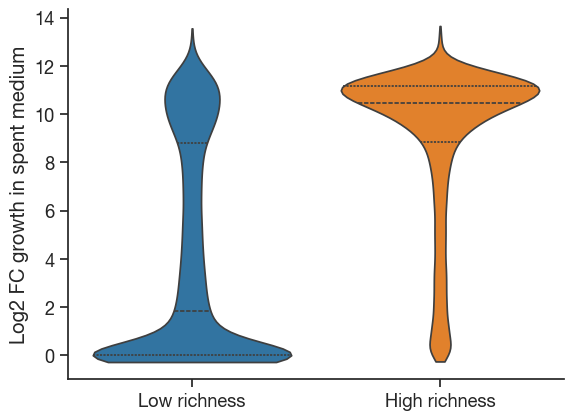

In [52]:
sns.violinplot(SM_df, x = 'Category', y = 'log2 FC', inner = 'quartile', hue = 'Category', palette='tab10', cut = 0)
sns.despine()
plt.xlabel('')
plt.ylabel('Log2 FC growth in spent medium')
# plt.yscale('log')

# Interactions

## In fresh medium

In [53]:
def run_single_pair_fresh(i, j, pair, C, D, K, n_cs, leakage, max_time, initial_abundance, initial_c_conc, dt, method):
    """Run a single pair culture in fresh medium"""
    R0 = np.zeros(n_cs)
    R0[j] = initial_c_conc
    
    if C[pair, j].min() < 1e-6:
        return None
    
    l = leakage * np.ones(2)
    N0 = np.ones(2) * initial_abundance
    
    c = CRM(2, n_cs, C=C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
    try:
        sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        if sol.success:
            return {'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j': j}
    except (RuntimeError, ValueError):
        pass
    
    return None

pairs = list(itertools.combinations(range(4), 2))
if run_simulations:
    # Prepare parameters for parallel processing
    fresh_params = []
    for i in indices:
        n_cs = df.loc[df.i==i, 'n_cs'].values[0]
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        
        for j in range(iterations):
            for pair in pairs:
                fresh_params.append((i, j, pair, C, D, K, n_cs, args.leakage, max_time, 
                                   initial_abundance, initial_c_conc, dt, method))
    
    # Run in parallel
    fresh_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_pair_fresh)(*params) for params in fresh_params
    )
    
    paired_fresh_culture_data = [r for r in fresh_results if r is not None]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1849370373889005s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09275603294372559s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08335089683532715s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:    3.5s
[Parallel(n_jobs=

In [54]:
fn_inter = results_folder / f'{run}_interactions_fresh.npz'

with open(fn_inter, 'wb') as f:
    np.savez(f, paired_fresh_culture_data)

In [55]:
len(paired_fresh_culture_data)

67990

# In spent medium

In [56]:
def run_single_pair_spent(i, j, k_spent, pair, C, D, K, n_cs, R0, leakage, max_time, initial_abundance, dt, method):
    """Run a single pair culture in spent medium"""
    l = leakage * np.ones(2)
    N0 = np.ones(2) * initial_abundance
    
    c = CRM(2, n_cs, C=C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
    try:
        sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        if sol.success:
            return {'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j': j, 'spent_medium_from': k_spent}
    except (RuntimeError, ValueError):
        pass
    
    return None

all_pairs = list(itertools.combinations(range(4), 2))
if run_simulations:
    # Prepare parameters for parallel processing
    spent_params = []
    for mcdata in monoculture_data:
        i = mcdata['i']
        j = mcdata['j']
        
        if np.isnan(mcdata['final_abundance']).any() or (mcdata['final_abundance'] == initial_abundance).any():
            continue
        if mcdata['final_resources'][j] > 0.1*initial_c_conc:
            continue

        if j > 2:
            continue

        k_spent = mcdata['species_no']
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        R0 = mcdata['final_resources'].copy()
        R0[R0 < 0] = 0
        n_cs = R0.shape[0]
        
        pairs = [p for p in all_pairs if k_spent not in p]
        for pair in pairs:
            spent_params.append((i, j, k_spent, pair, C, D, K, n_cs, R0, args.leakage, max_time, initial_abundance, dt, method))
    
    # Run in parallel
    spent_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_pair_spent)(*params) for params in spent_params
    )
    
    paired_spent_culture_data = [r for r in spent_results if r is not None]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.005482196807861328s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.016079187393188477s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.01779913902282715s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.029348134994506836s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.05243325233459473s.) Setting batch_size=32.
[Para

In [57]:
fn_sm_inter = results_folder / f'{run}_interactions_spent.npz'
with open(fn_sm_inter, 'wb') as f:
    np.savez(f, paired_spent_culture_data)

# Compare interactions

In [263]:
M_df = pd.DataFrame(monoculture_data)

In [264]:
M_df['monoculture_abundance'] = [x if np.isnan(x) else x[0] for x in M_df['final_abundance']]

In [265]:
M_df.rename(columns={'species_no':'species'}, inplace=True)

In [266]:
M_df.dropna(inplace=True)

In [267]:
# SM_df = pd.DataFrame(spent_monoculture_data)

In [268]:
# SM_df['monoculture_abundance'] = [x if np.isnan(x) else x[0] for x in SM_df['final_abundance']]
SM_df.rename(columns={'species_no':'species'}, inplace=True)

In [269]:
SM_df.dropna(inplace=True)

In [318]:
SIt_df = pd.DataFrame(paired_spent_culture_data)

In [319]:
SIt_df[['Species 1', 'Species 2']] = pd.DataFrame(SIt_df.pair.tolist(), index=SIt_df.index)

In [320]:
SIt_df[['Abundance 1', 'Abundance 2']] = pd.DataFrame(SIt_df.final_abundance.tolist(), index=SIt_df.index)

In [321]:
sm_ijk_to_abundance = SM_df.set_index(['i', 'j', 'spent_medium_from', 'species'])['monoculture_abundance'].to_dict()

In [322]:
SIt_df['Spent medium mono abundance 1'] = SIt_df.apply(lambda row: sm_ijk_to_abundance.get((row['i'], row['j'], row['spent_medium_from'], row['Species 1'])), axis=1)
SIt_df['Spent medium mono abundance 2'] = SIt_df.apply(lambda row: sm_ijk_to_abundance.get((row['i'], row['j'], row['spent_medium_from'], row['Species 2'])), axis=1)

In [323]:
SIt_df['Interaction 1'] = np.log10(SIt_df['Abundance 1'] / SIt_df['Spent medium mono abundance 1'])
SIt_df['Interaction 2'] = np.log10(SIt_df['Abundance 2'] / SIt_df['Spent medium mono abundance 2'])

In [324]:
SIt_df['Min mono abundance'] = SIt_df[['Spent medium mono abundance 1', 'Spent medium mono abundance 2']].min(axis=1)

In [326]:
SIt_df['Category'] = SIt_df.i.map(plot_df['Category'].to_dict())

In [330]:
SIt_df.columns

Index(['final_abundance', 'pair', 'i', 'j', 'spent_medium_from', 'Species 1',
       'Species 2', 'Abundance 1', 'Abundance 2',
       'Spent medium mono abundance 1', 'Spent medium mono abundance 2',
       'Interaction 1', 'Interaction 2', 'Min mono abundance', 'Category'],
      dtype='object')

In [354]:
SI_df = pd.melt(SIt_df, id_vars = ['i', 'j','spent_medium_from', 'pair', 'Category', 'Min mono abundance', 'Species 1', 'Species 2', 'Abundance 1', 'Abundance 2'], value_vars=['Interaction 1', 'Interaction 2'], value_name='Interaction', var_name = 'Interaction #')

In [ ]:

df['Dominant species'] = df[['N1', 'N2', 'N3', 'N4']].idxmax(axis=1).str.strip('N').astype(int)
ij_to_dominant = df.set_index(['i', 'cs_j'])['Dominant species'].to_dict()

In [355]:
SI_df['Dominant'] = SI_df.apply(lambda row: ij_to_dominant[(row['i'], row['j'])], axis=1)

<Axes: ylabel='Interaction'>

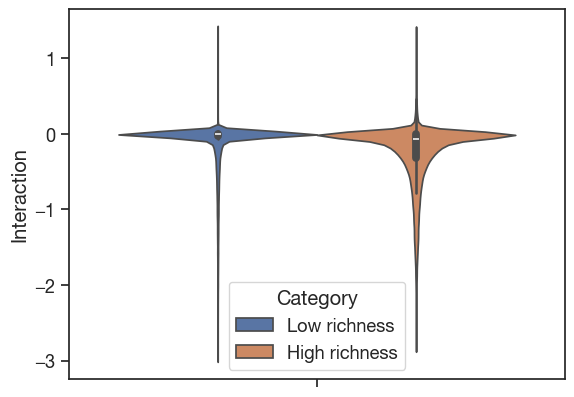

In [356]:
sns.violinplot(SI_df, y = 'Interaction', hue = 'Category')

In [380]:
idx = SI_df['Min mono abundance'] > 1e-2

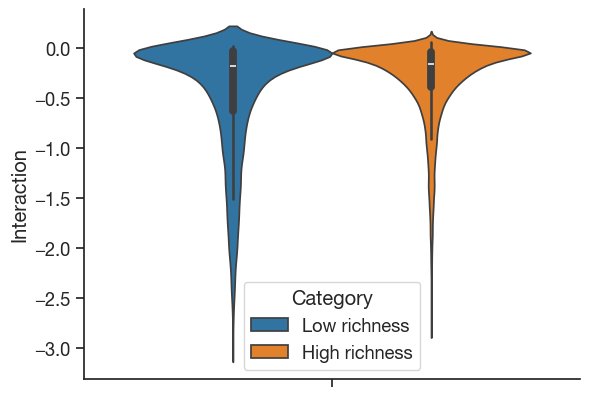

In [381]:
sns.violinplot(SI_df.loc[idx], y = 'Interaction', hue = 'Category', palette='tab10')
sns.despine()

In [370]:
SI_df.loc[idx].groupby('Category')['Interaction'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
High richness,23068.0,-0.299670,0.388555,-2.791976,-0.389413,-0.156578,-0.040672,0.066116
Low richness,6510.0,-0.435577,0.569138,-2.942360,-0.623866,-0.177812,-0.030517,0.027301


In [359]:
SI_red = SI_df.loc[idx]
SI_red = SI_red.loc[SI_red['Dominant'] == SI_red['spent_medium_from']]

<Axes: ylabel='Interaction'>

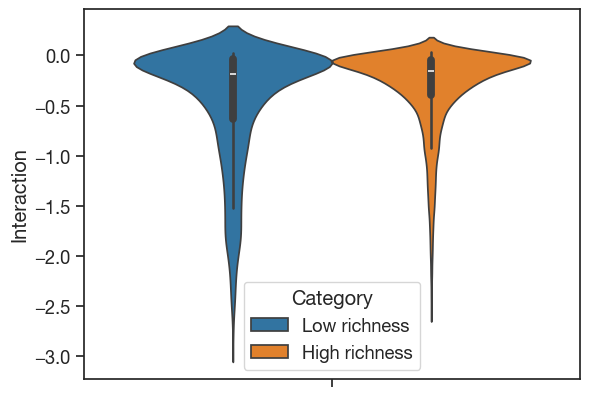

In [360]:
sns.violinplot(SI_red, y = 'Interaction', hue = 'Category', palette='tab10')


In [363]:
SI_red.groupby('Category').Interaction.describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
High richness,4144.0,-0.307070,0.397802,-2.501780,-0.395562,-0.159464,-0.041466,0.032162
Low richness,1438.0,-0.442429,0.573944,-2.786863,-0.629749,-0.180737,-0.031325,0.027301


In [364]:
# Map on i nd j to i and cs_j
richness_dict = df.set_index(['i', 'cs_j'])['richness'].to_dict()
SI_df['Richness'] = SI_df.apply(lambda row: richness_dict[(row['i'], row['j'])], axis=1)

In [366]:
# Calculate shannon diversity of monoculture abundances in spent medium
from scipy.stats import entropy
def shannon_diversity(abundances):
    abundances = np.array(abundances)
    abundances = abundances[abundances > 0]
    proportions = abundances / np.sum(abundances)
    return entropy(proportions)
df['Shannon'] = df.apply(lambda row: shannon_diversity([row['N1'], row['N2'], row['N3'], row['N4']]), axis=1)

In [367]:
shannon_dict = df.set_index(['i', 'cs_j'])['Shannon'].to_dict()
SI_df['Shannon'] = SI_df.apply(lambda row: shannon_dict[(row['i'], row['j'])], axis=1)

In [400]:
def shannon(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return -np.sum([pi*np.log(pi) for pi in p])

df['Shannon 2'] = df.apply(lambda row: shannon([row['N1'], row['N2'], row['N3'], row['N4']]), axis=1)

In [401]:
df

,i,cs_j,n_cs,K_std,csp,richness,N1,N2,N3,N4,Dominant species,Shannon,Shannon 2
0,0,0,29,1.297766,0.214189,2,9.940868e-08,9.999828e-08,9.564276e-01,4.142556e-03,3,0.027794,0.027794
1,0,1,29,1.297766,0.214189,2,9.419840e-01,9.999842e-08,9.998388e-08,3.894045e-02,1,0.166986,0.166986
2,0,2,29,1.297766,0.214189,3,9.994713e-08,4.336320e-02,1.953526e-01,7.067726e-01,4,0.684691,0.684691
3,0,3,29,1.297766,0.214189,3,9.730122e-01,2.300293e-04,9.995734e-08,1.001513e-02,1,0.059042,0.059042
4,0,4,29,1.297766,0.214189,3,4.454022e-03,9.264327e-01,9.979435e-08,3.252208e-02,2,0.176882,0.176882
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,3,22,0.861405,0.257059,2,9.377382e-01,3.217932e-02,9.999607e-08,9.995539e-08,1,0.145623,0.145623
79996,9999,4,22,0.861405,0.257059,1,9.998607e-08,8.538198e-01,9.992303e-08,9.808577e-08,2,0.000006,0.000006
79997,9999,5,22,0.861405,0.257059,2,9.558639e-08,5.184231e-01,3.930953e-01,9.990603e-08,2,0.683668,0.683668
79998,9999,6,22,0.861405,0.257059,2,8.724009e-01,9.891497e-08,9.999032e-08,4.815154e-02,1,0.205257,0.205257


<Axes: ylabel='Shannon'>

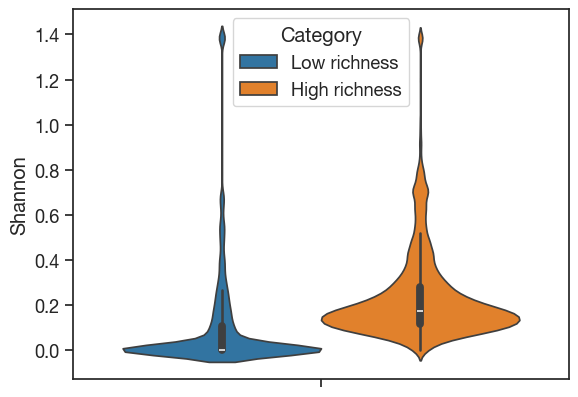

In [369]:
sns.violinplot(SI_df, y='Shannon', hue='Category', palette='tab10')

# Fresh interactions

In [382]:
FIt_df = pd.DataFrame(paired_fresh_culture_data)
# SIt_df = pd.DataFrame(paired_spent_culture_data)

In [383]:
FI_df = FIt_df.explode(column=['final_abundance', 'pair'])


In [384]:
FI_df.rename(columns={'pair':'species'}, inplace=True)


In [385]:
FI_df['pair'] = FI_df.index.map(FIt_df['pair'].to_dict())


In [386]:
FI_df.reset_index(drop=True, inplace=True)


In [387]:
FI_df['species'] = FI_df['species'].astype(int)

(array([ 1303.,  2938.,  3555.,  4410.,  6391.,  9892., 19095., 11349.,
         7440., 69607.]),
 array([-4.97584432e+00, -4.47826094e+00, -3.98067755e+00, -3.48309417e+00,
        -2.98551078e+00, -2.48792740e+00, -1.99034401e+00, -1.49276063e+00,
        -9.95177246e-01, -4.97593862e-01, -1.04778669e-05]),
 <BarContainer object of 10 artists>)

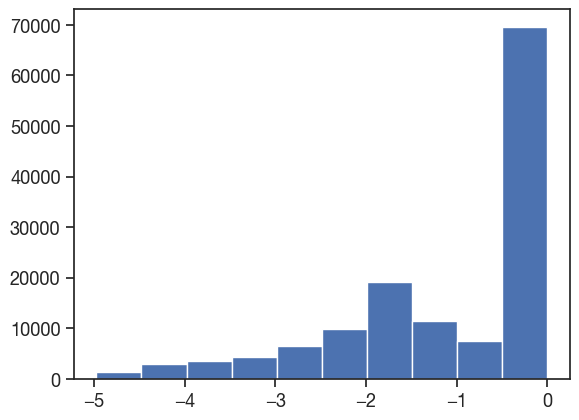

In [388]:
plt.hist(np.log10(FI_df.final_abundance.astype(float)))
# plt.xscale('log')

In [390]:
FIM_df = pd.merge(left = FI_df, right = M_df.loc[:, ['monoculture_abundance', 'i', 'j', 'species']], on=['i', 'j', 'species'], how = 'left')
# SIM_df = pd.merge(left = SI_df, right = SM_df.loc[:, ['spent_medium_from', 'species', 'i', 'j', 'monoculture_abundance', 'R0']], how = 'left')

In [391]:
FIM_df.dropna(inplace=True)
# SIM_df.dropna(inplace = True)

In [392]:
FIM_df['final_abundance'] = FIM_df['final_abundance'].astype(float)
# SIM_df['final_abundance'] = SIM_df['final_abundance'].astype(float)

In [393]:
FIM_df['log10 FC'] = np.log10(FIM_df['final_abundance'] / FIM_df['monoculture_abundance'])
# SIM_df['log10 FC'] = np.log2(SIM_df['final_abundance'] / SIM_df['monoculture_abundance'])

In [394]:
FIM_df['Category'] = FIM_df.i.map(plot_df['Category'].to_dict())
# SIM_df['Category'] = SIM_df.i.map(plot_df['Category'].to_dict())

In [395]:
FIM_df.loc[FIM_df['log10 FC'] > 0.5]

,final_abundance,species,i,j,pair,monoculture_abundance,log10 FC,Category
5,0.000188,3,1990,0,"(0, 3)",0.000023,0.905653,Low richness
9,0.000199,3,1990,0,"(1, 3)",0.000023,0.931187,Low richness
56,0.017069,1,1990,5,"(1, 3)",0.000769,1.346138,Low richness
102,0.010714,0,7283,2,"(0, 2)",0.002841,0.576547,Low richness
104,0.031020,0,7283,2,"(0, 3)",0.002841,1.038225,Low richness
...,...,...,...,...,...,...,...,...
135922,0.001748,0,7554,2,"(0, 2)",0.000378,0.665161,High richness
135924,0.012963,0,7554,2,"(0, 3)",0.000378,1.535410,High richness
135937,0.016049,3,7554,3,"(0, 3)",0.000577,1.444315,High richness
135941,0.023100,3,7554,3,"(1, 3)",0.000577,1.602468,High richness


# Statistical comparison of log10 FC between categories in SIM_df

In [402]:
# Statistical tests
from scipy import stats

# Separate data by category
low_richness = SI_df[SI_df['Category'] == 'Low richness']['Interaction'].dropna()
high_richness = SI_df[SI_df['Category'] == 'High richness']['Interaction'].dropna()

# Mann-Whitney U test (non-parametric)
statistic, p_value = stats.mannwhitneyu(low_richness, high_richness, alternative='two-sided')
print(f"Mann-Whitney U test:")
print(f"  Statistic: {statistic:.2f}")
print(f"  P-value: {p_value:.4e}")

# t-test (parametric, for comparison)
t_stat, t_pval = stats.ttest_ind(low_richness, high_richness)
print(f"\nIndependent t-test:")
print(f"  t-statistic: {t_stat:.2f}")
print(f"  P-value: {t_pval:.4e}")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(low_richness)-1)*low_richness.std()**2 + 
                      (len(high_richness)-1)*high_richness.std()**2) / 
                     (len(low_richness) + len(high_richness) - 2))
cohens_d = (low_richness.mean() - high_richness.mean()) / pooled_std
print(f"\nEffect size (Cohen's d): {cohens_d:.3f}")

Mann-Whitney U test:
  Statistic: 1659481656.00
  P-value: 0.0000e+00

Independent t-test:
  t-statistic: 52.28
  P-value: 0.0000e+00

Effect size (Cohen's d): 0.335


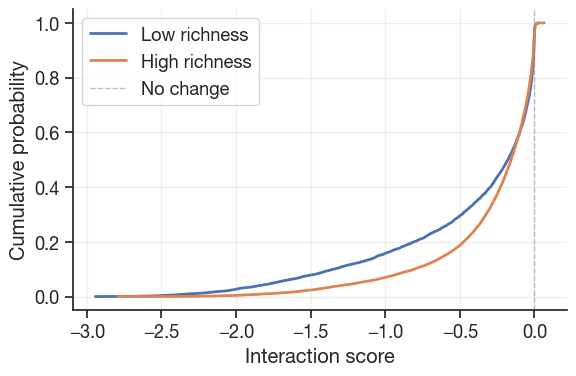

In [404]:
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(6, 4))
idx = SI_df['Min mono abundance'] > 1e-2
red_df = SI_df.loc[idx]
for category in ['Low richness', 'High richness']:
    data = red_df[red_df['Category'] == category]['Interaction'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, label=category, linewidth=2)

plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No change')
plt.xlabel('Interaction score')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()

In [414]:
SI_df['Max mono abundance'] = SI_df[['Abundance 1', 'Abundance 2']].max(axis=1)


In [415]:
SI_df

,i,j,spent_medium_from,pair,Category,Min mono abundance,Species 1,Species 2,Abundance 1,Abundance 2,Interaction #,Interaction,Dominant,Richness,Shannon,Max mono abundance
0,1990,0,0,"(1, 2)",Low richness,0.000022,1,2,0.000023,0.002307,Interaction 1,0.008245,1,1,0.000005,0.002307
1,1990,0,0,"(1, 3)",Low richness,0.000022,1,3,0.000022,0.000129,Interaction 1,0.000665,1,1,0.000005,0.000129
2,1990,0,0,"(2, 3)",Low richness,0.000129,2,3,0.002287,0.000119,Interaction 1,-0.004626,1,1,0.000005,0.002287
3,1990,0,1,"(0, 2)",Low richness,0.000028,0,2,0.000125,0.000027,Interaction 1,-0.001457,1,1,0.000005,0.000125
4,1990,0,1,"(0, 3)",Low richness,0.000126,0,3,0.000122,0.000761,Interaction 1,-0.014168,1,1,0.000005,0.000761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97537,7554,2,2,"(0, 3)",High richness,0.000190,0,3,0.000190,0.000575,Interaction 2,-0.003419,3,4,0.086745,0.000575
97538,7554,2,2,"(1, 3)",High richness,0.000580,1,3,0.006715,0.000365,Interaction 2,-0.200727,3,4,0.086745,0.006715
97539,7554,2,3,"(0, 1)",High richness,0.013402,0,1,0.011943,0.006545,Interaction 2,-0.399123,3,4,0.086745,0.011943
97540,7554,2,3,"(0, 2)",High richness,0.002899,0,2,0.013280,0.000538,Interaction 2,-0.731577,3,4,0.086745,0.013280


<Axes: xlabel='Interaction', ylabel='Density'>

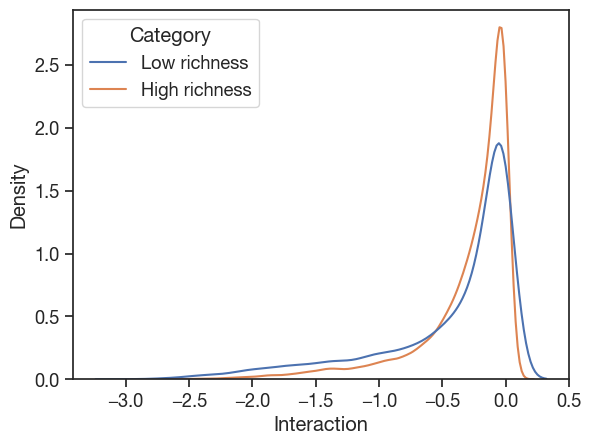

In [424]:
sns.kdeplot(SI_df.loc[idx], x = 'Interaction', hue = 'Category', common_norm=False)

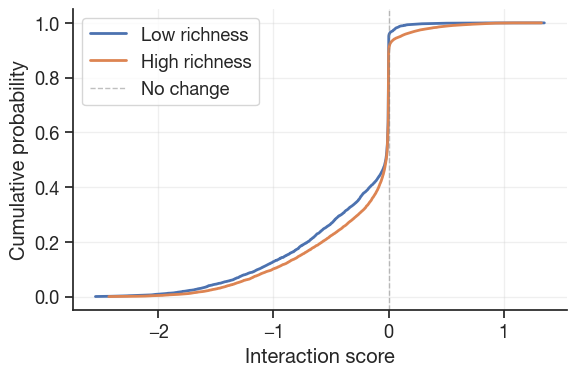

In [416]:
idx2 = (SI_df['Min mono abundance'] < 1e-2)& (SI_df['Max mono abundance']>1e-2)
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(6, 4))
red_df = SI_df.loc[idx2]
for category in ['Low richness', 'High richness']:
    data = red_df[red_df['Category'] == category]['Interaction'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, label=category, linewidth=2)

plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No change')
plt.xlabel('Interaction score')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()

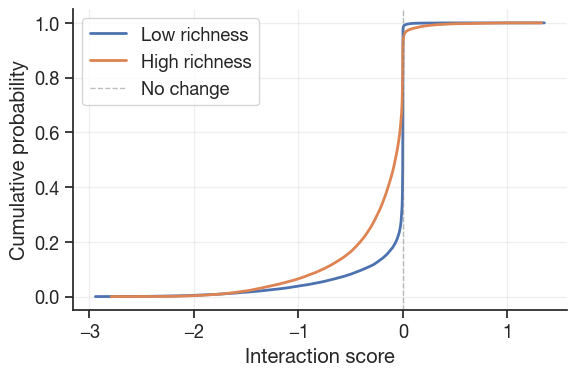

In [405]:
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(6, 4))
for category in ['Low richness', 'High richness']:
    data = SI_df[SI_df['Category'] == category]['Interaction'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, label=category, linewidth=2)

plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No change')
plt.xlabel('Interaction score')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()